In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from transformers import SamModel, SamProcessor
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

# -----------------------------
# Load models
# -----------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

# SAM
sam_model = SamModel.from_pretrained("facebook/sam-vit-base").to(device)
sam_processor = SamProcessor.from_pretrained("facebook/sam-vit-base")

# GroundingDINO
dino_model_id = "IDEA-Research/grounding-dino-tiny"
dino_processor = AutoProcessor.from_pretrained(dino_model_id)
dino_model = AutoModelForZeroShotObjectDetection.from_pretrained(dino_model_id).to(device)

print("Models loaded!")

/DATA/home/jgarcia/miniconda3/envs/sam_env_c5/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 314/314 [00:00<00:00, 58766.30it/s]
The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 1

Models loaded!


Loading seqmap...


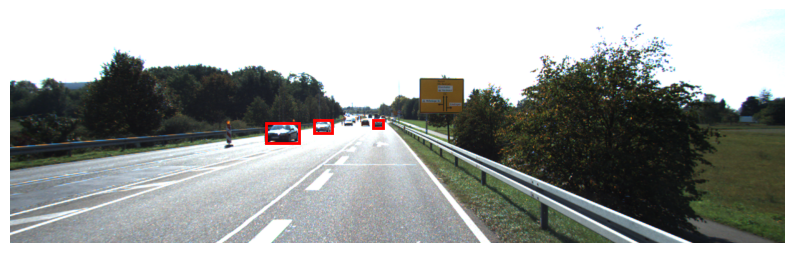

In [4]:
import sys
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.append("/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/src")
from utils.kitti_dataset_motsio2 import KittiDataset


dataset = KittiDataset(
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/training",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/data/KITTI-MOTS/instances_txt",
    "/DATA/home/jgarcia/SpectralSegmentation/C5-Project/Week2/src/utils/val.seqmap",
    only_mask=True
)

import random
idx = random.randint(0, len(dataset)-1)

image, target = dataset[idx]

# Convert tensor image to numpy
img = image.permute(1, 2, 0).numpy()

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(img)

boxes = target["boxes"]

for box in boxes:
    x1, y1, x2, y2 = box.tolist()
    
    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    
    ax.add_patch(rect)

plt.axis("off")
plt.show()

In [ ]:
prompt_sets = [

# Baseline
{
"name": "baseline",
"car_prompts": ["car"],
"pedestrian_prompts": ["person"]
},

# Synonyms
{
"name": "synonyms",
"car_prompts": ["car", "automobile", "vehicle"],
"pedestrian_prompts": ["person", "pedestrian", "human"]
},

# Context prompts
{
"name": "context",
"car_prompts": ["car on road", "road vehicle"],
"pedestrian_prompts": ["person walking", "walking pedestrian"]
}

]

import numpy as np

def compute_iou(boxA, boxB):

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    union = areaA + areaB - inter

    if union == 0:
        return 0

    return inter / union

from PIL import Image

def run_dino(image_np, prompts):

    text = ". ".join(prompts)

    image_pil = Image.fromarray((image_np*255).astype("uint8"))

    inputs = dino_processor(images=image_pil, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    results = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.35,
    text_threshold=0.25,
    target_sizes=[image_pil.size[::-1]]
    )[0]

    return results["boxes"].cpu().numpy()

from tqdm import tqdm

def evaluate_prompt_set(dataset, prompt_set):

    TP = 0
    FP = 0
    FN = 0

    prompts = prompt_set["car_prompts"] + prompt_set["pedestrian_prompts"]

    for i in tqdm(range(len(dataset))):

        image, target = dataset[i]

        img = image.permute(1,2,0).numpy()
        gt_boxes = target["boxes"].numpy()

        pred_boxes = run_dino(img, prompts)

        matched_gt = set()

        for pred in pred_boxes:

            best_iou = 0
            best_gt = -1

            for j, gt in enumerate(gt_boxes):

                iou = compute_iou(pred, gt)

                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= 0.5 and best_gt not in matched_gt:
                TP += 1
                matched_gt.add(best_gt)
            else:
                FP += 1

        FN += len(gt_boxes) - len(matched_gt)

    precision = TP / (TP + FP + 1e-6)
    recall = TP / (TP + FN + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)

    return precision, recall, f1

In [111]:
def run_dino(image_np, prompts):

    text = ". ".join(prompts)

    image_pil = Image.fromarray((image_np*255).astype("uint8"))

    inputs = dino_processor(images=image_pil, text=text, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = dino_model(**inputs)

    results = dino_processor.post_process_grounded_object_detection(
        outputs,
        inputs.input_ids,
        threshold=0.0,      # importante para mAP
        text_threshold=0.25,
        target_sizes=[image_pil.size[::-1]]
    )[0]

    boxes = results["boxes"].cpu().numpy()
    scores = results["scores"].cpu().numpy()

    return boxes, scores

def compute_ap50(dataset, prompt_set):

    prompts = prompt_set["car_prompts"] + prompt_set["pedestrian_prompts"]

    all_scores = []
    all_matches = []
    total_gt = 0

    for i in tqdm(range(len(dataset))):

        image, target = dataset[i]

        img = image.permute(1,2,0).numpy()
        gt_boxes = target["boxes"].numpy()

        total_gt += len(gt_boxes)

        pred_boxes, scores = run_dino(img, prompts)

        matched_gt = set()

        for box, score in zip(pred_boxes, scores):

            best_iou = 0
            best_gt = -1

            for j, gt in enumerate(gt_boxes):

                iou = compute_iou(box, gt)

                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= 0.5 and best_gt not in matched_gt:
                match = 1
                matched_gt.add(best_gt)
            else:
                match = 0

            all_scores.append(score)
            all_matches.append(match)

    # ordenar por score
    order = np.argsort(-np.array(all_scores))
    matches = np.array(all_matches)[order]

    tp = np.cumsum(matches)
    fp = np.cumsum(1 - matches)

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (total_gt + 1e-6)

    ap = np.trapz(precision, recall)

    return ap

map_results = {}

for prompt_set in prompt_sets:

    print("Evaluating:", prompt_set["name"])

    ap50 = compute_ap50(dataset, prompt_set)

    map_results[prompt_set["name"]] = ap50

print("\nMAP@50 RESULTS")

for k,v in map_results.items():
    print(k, v)

Evaluating: baseline


100%|██████████| 2981/2981 [03:51<00:00, 12.88it/s]
/tmp/ipykernel_1787916/1012598448.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ap = np.trapz(precision, recall)


Evaluating: synonyms


100%|██████████| 2981/2981 [03:52<00:00, 12.81it/s]


Evaluating: context


100%|██████████| 2981/2981 [03:53<00:00, 12.79it/s]



MAP@50 RESULTS
baseline 0.6370081267906247
synonyms 0.6876869098619245
context 0.4316989638807226


In [12]:
from tqdm import tqdm

results = {}

for prompt_set in prompt_sets:

    print("Evaluating:", prompt_set["name"])

    precision, recall, f1 = evaluate_prompt_set(dataset, prompt_set)

    results[prompt_set["name"]] = (precision, recall, f1)

print("\nRESULTS")
for k,v in results.items():
    print(k, v)

Evaluating: baseline


100%|██████████| 2981/2981 [02:55<00:00, 17.01it/s]


Evaluating: synonyms


100%|██████████| 2981/2981 [02:53<00:00, 17.23it/s]


Evaluating: context


100%|██████████| 2981/2981 [02:52<00:00, 17.26it/s]


RESULTS
baseline (0.7388193201412423, 0.653481012600784, 0.69353434648242)
synonyms (0.5359533468288056, 0.9290611813529306, 0.6797654222448052)
context (0.5618663893213066, 0.38001054848980215, 0.45338179441844906)


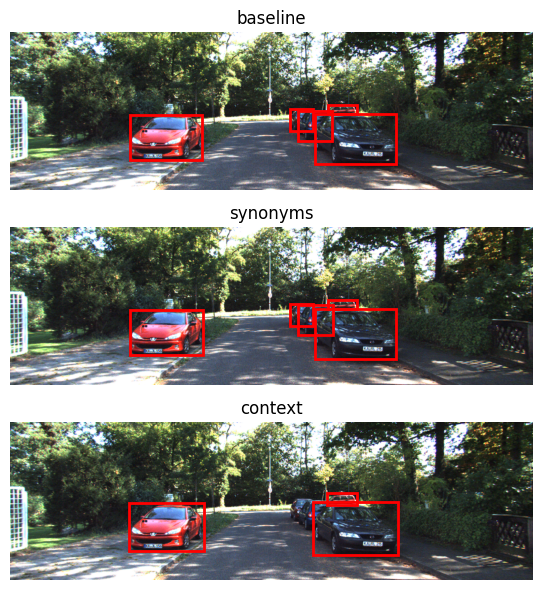

In [36]:
# Pick an image

idxs = random.sample(range(len(dataset)), 1)

for idx in idxs:
    image, target = dataset[idx]
    img = image.permute(1,2,0).numpy()

    fig, axes = plt.subplots(3, 1, figsize=(18,6))

    for ax, prompt_set in zip(axes, prompt_sets):

        prompts = prompt_set["car_prompts"] + prompt_set["pedestrian_prompts"]

        boxes = run_dino(img, prompts)

        ax.imshow(img)
        ax.set_title(prompt_set["name"])

        for box in boxes:

            x1,y1,x2,y2 = box

            rect = patches.Rectangle(
                (x1,y1),
                x2-x1,
                y2-y1,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

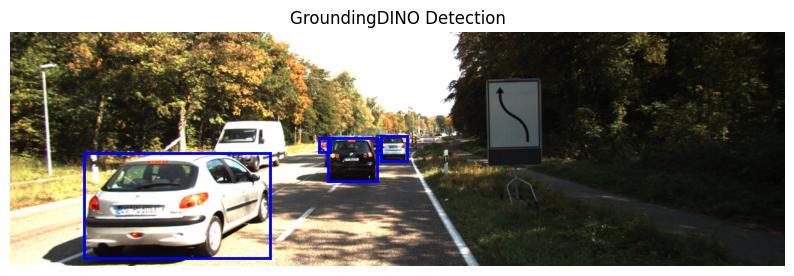

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


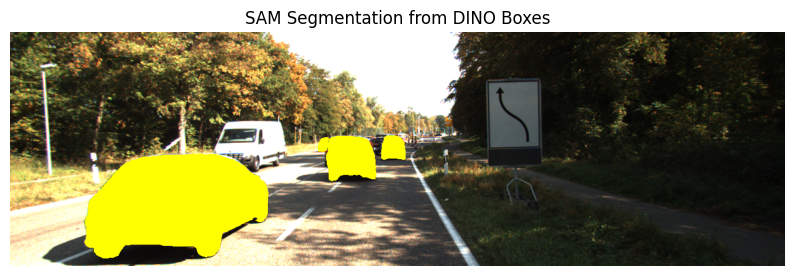

In [108]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

# -----------------------------
# Load image
# -----------------------------

random_idx = random.randint(0, len(dataset)-1)

image, target = dataset[random_idx]

image_np = image.permute(1,2,0).numpy()
image_pil = Image.fromarray((image_np*255).astype("uint8"))

# -----------------------------
# Text prompt
# -----------------------------

text_labels = [["car", "automobile", "vehicle", "person", "pedestrian", "human"]]

inputs = dino_processor(
    images=image_pil,
    text=text_labels,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = dino_model(**inputs)

result = dino_processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.35,
    text_threshold=0.25,
    target_sizes=[image_pil.size[::-1]]
)[0]

# -----------------------------
# Run SAM for each box
# -----------------------------

masks = []

for box in result["boxes"]:

    box = box.tolist()
    input_boxes = [[box]]   # correct format for SAM

    sam_inputs = sam_processor(
        image_pil,
        input_boxes=input_boxes,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        sam_outputs = sam_model(**sam_inputs)

    mask = sam_processor.image_processor.post_process_masks(
        sam_outputs.pred_masks.cpu(),
        sam_inputs["original_sizes"].cpu(),
        sam_inputs["reshaped_input_sizes"].cpu()
    )[0][0][0].numpy()

    masks.append(mask)

# -----------------------------------
# 1️⃣ GroundingDINO visualization
# -----------------------------------

fig, ax = plt.subplots(1, figsize=(10,6))
ax.imshow(image_np)

for box, score, label in zip(result["boxes"], result["scores"], result["labels"]):

    x1, y1, x2, y2 = box.tolist()
    w = x2 - x1
    h = y2 - y1

    rect = patches.Rectangle(
        (x1, y1),
        w,
        h,
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rect)

ax.set_title("GroundingDINO Detection")
ax.axis("off")

plt.show()

# -----------------------------------
# 2️⃣ SAM segmentation visualization
# -----------------------------------

result_img = image_np.copy()

for mask in masks:

    mask = mask.astype(bool)
    result_img[mask] = [255,255,0]

fig, ax = plt.subplots(1, figsize=(10,6))
ax.imshow(result_img)

ax.set_title("SAM Segmentation from DINO Boxes")
ax.axis("off")

plt.show()